# Análise Tática: A Metamorfose do Manchester City (2020/2021)
#### **Do Ataque Tradicional ao Sistema de Falso 9**
Esta análise detalha a transformação do modelo ofensivo de Pep Guardiola após a lesão de Sergio Agüero em 24 de outubro de 2020. Comparamos o comportamento da linha de frente clássica com a fluidez do sistema que redefiniu a temporada do título.

In [1]:
!pip install soccerdata pandas matplotlib mplsoccer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.2/171.2 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import soccerdata as sd

In [3]:
print("Fetching data from Understat... This might take a moment.")
# Initialize Understat wrapper for the 20/21 Premier League season
understat = sd.Understat(leagues="ENG-Premier League", seasons="2020/2021")

# CORRECTED METHOD: read_shot_events()
all_shots = understat.read_shot_events()

# Reset index to convert MultiIndex (league, season, game, etc.) into regular columns
df_shots = all_shots.reset_index()

print(f"Successfully loaded {len(df_shots)} shots from the season.")

Fetching data from Understat... This might take a moment.


[05/15/26 10:28:50] INFO     Saving cached data to /root/soccerdata/data/Understat                   ]8;id=9114728;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=9114729;file:///usr/local/lib/python3.12/dist-packages/soccerdata/_common.py#250\250]8;;\

Successfully loaded 9235 shots from the season.


In [10]:
# Filter specifically for Manchester City shots
mc_shots = df_shots[df_shots['team'].str.contains('Manchester City', case=False, na=False)].copy()
#mc_shots = df_shots.copy()

# Ensure the date column is a datetime object
mc_shots['date'] = pd.to_datetime(mc_shots['date'])

print(f"Manchester City total shots found: {len(mc_shots)}")

# FIXED: Changed 'x' and 'y' to 'location_x' and 'location_y'
mc_shots[['team','date', 'player', 'location_x', 'location_y', 'xg', 'result']].head()

Manchester City total shots found: 601


,team,date,player,location_x,location_y,xg,result
394,Manchester City,2020-09-21 19:15:00,Benjamin Mendy,0.761,0.501,0.028904,Blocked Shot
395,Manchester City,2020-09-21 19:15:00,Fernandinho,0.938,0.292,0.069821,Missed Shot
396,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.848,0.555,0.12107,Saved Shot
397,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.735,0.371,0.022151,Saved Shot
398,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.933,0.678,0.092717,Goal


In [7]:
!zip -r mancity_analysis.zip /root/soccerdata

# 2. Trigger the browser download automatically
from google.colab import files
files.download('mancity_analysis.zip')

  adding: root/soccerdata/ (stored 0%)
  adding: root/soccerdata/logs/ (stored 0%)
  adding: root/soccerdata/logs/error.log (stored 0%)
  adding: root/soccerdata/logs/info.log (deflated 71%)
  adding: root/soccerdata/data/ (stored 0%)
  adding: root/soccerdata/data/Understat/ (stored 0%)
  adding: root/soccerdata/data/Understat/match_14554.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14524.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14095.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14792.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14712.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14549.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14797.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14575.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14473.json (deflated 88%)
  adding: root/soccerdata/data/Understat/match_14656.j

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

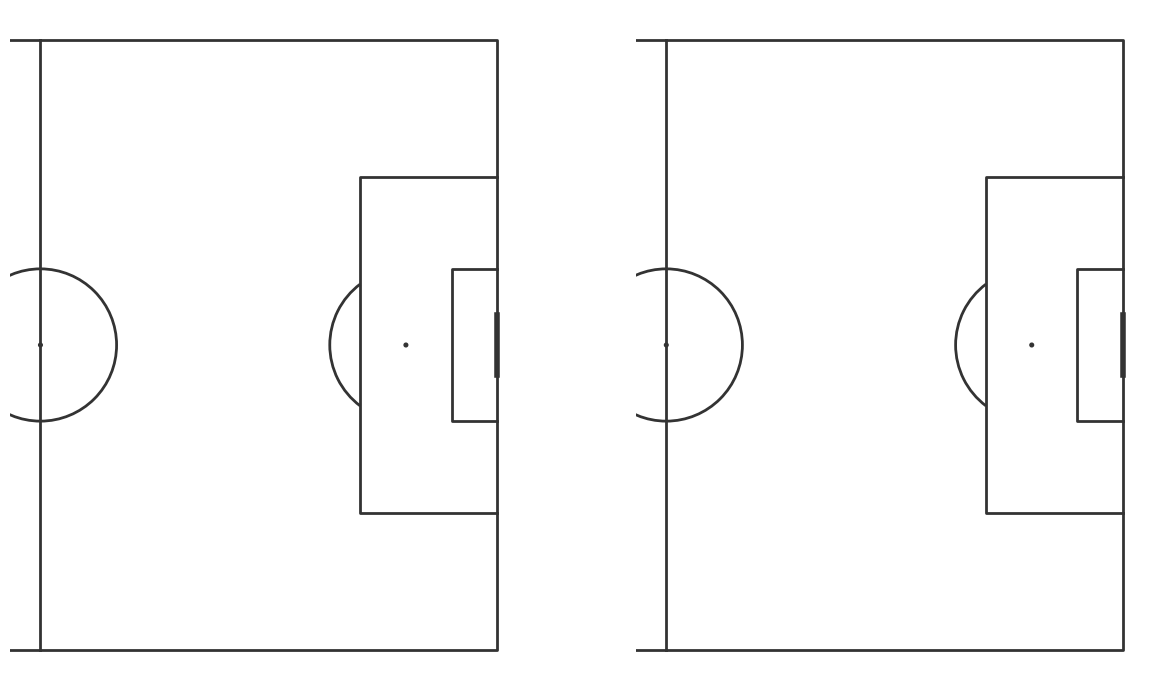

In [21]:
# 1. Definindo o marco temporal da lesão
data_lesao = '2020-10-24'

# Garantir formato datetime
mc_shots['date'] = pd.to_datetime(mc_shots['date'])

# Transformação de Coordenadas (Understat 0-1 -> StatsBomb 120x80)
if 'x_sb' not in mc_shots.columns:
    mc_shots['x_sb'] = mc_shots['location_x'] * 120
    mc_shots['y_sb'] = mc_shots['location_y'] * 80

# 2. Máscaras de Período (Antes e Depois da lesão)
antes_mask = mc_shots['date'] <= data_lesao
depois_mask = mc_shots['date'] > data_lesao

# 3. Máscaras de Jogadores
# Sistema Tradicional: Atacantes de ofício no início da temporada
trad_mask = mc_shots['player'].str.contains('Aguero|Agüero|Gabriel Jesus|Sterling', na=False, case=False)

# Sistema Falso 9: Meias e pontas construtores
falso9_mask = mc_shots['player'].str.contains('Phil Foden|Gundogan|Gündogan|De Bruyne|Bernardo Silva', na=False, case=False)

# 4. Cruzando as máscaras (Período + Jogadores Específicos)
trad_shots_antes = mc_shots[trad_mask & antes_mask].copy()
falso9_shots_depois = mc_shots[falso9_mask & depois_mask].copy()


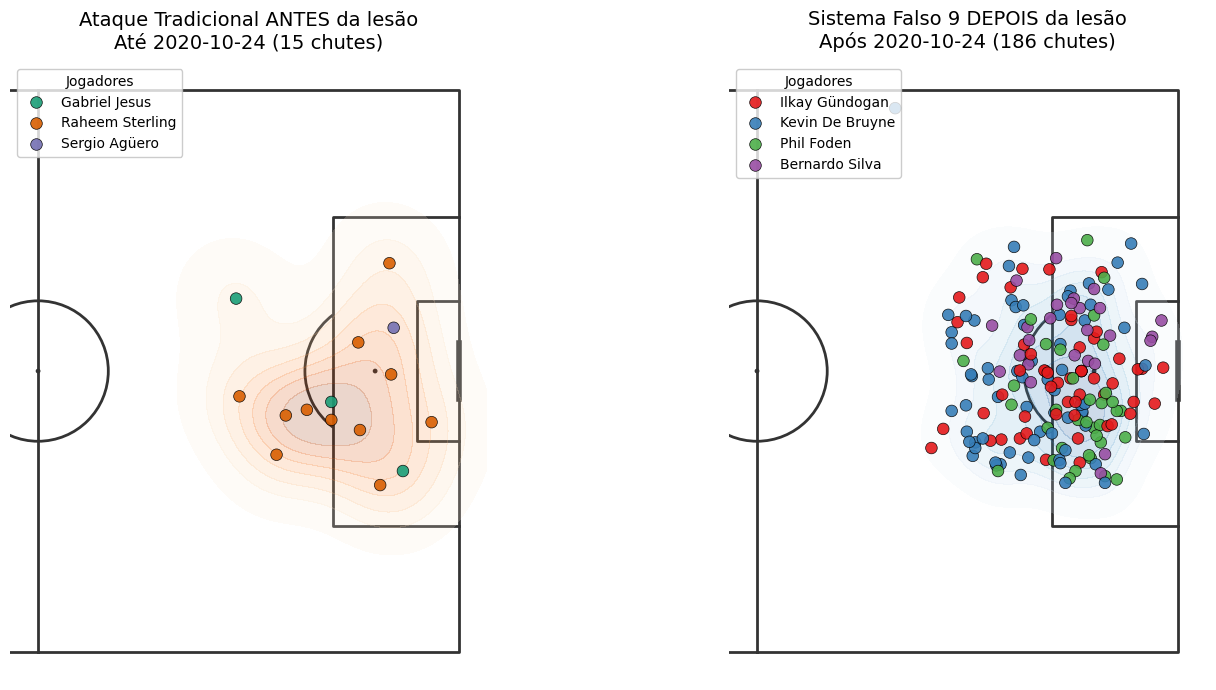

In [24]:

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')

# =========================================================
# PLOT 1: Sistema Tradicional (ANTES de 24/10/2020)
# =========================================================
# Verificando se há dados suficientes para não quebrar a mancha de calor
if len(trad_shots_antes) > 2:
    sns.kdeplot(x=trad_shots_antes['x_sb'], y=trad_shots_antes['y_sb'], ax=ax[0],
                fill=True, cmap='Oranges', thresh=0.05, levels=8, alpha=0.2)

# Scatter plot separando cada jogador por cor
sns.scatterplot(data=trad_shots_antes, x='x_sb', y='y_sb', hue='player',
                palette='Dark2', s=70, edgecolor='black', linewidth=0.5,
                alpha=0.9, ax=ax[0])

ax[0].set_title(f'Ataque Tradicional ANTES da lesão\nAté {data_lesao} ({len(trad_shots_antes)} chutes)', fontsize=14, pad=10)
ax[0].legend(title='Jogadores', loc='upper left', frameon=True,
             facecolor='white', edgecolor='silver', fontsize=10)

# =========================================================
# PLOT 2: Sistema Falso 9 (DEPOIS de 24/10/2020)
# =========================================================
if len(falso9_shots_depois) > 2:
    sns.kdeplot(x=falso9_shots_depois['x_sb'], y=falso9_shots_depois['y_sb'], ax=ax[1],
                fill=True, cmap='Blues', thresh=0.05, levels=8, alpha=0.2)

# Scatter plot separando cada jogador por cor
sns.scatterplot(data=falso9_shots_depois, x='x_sb', y='y_sb', hue='player',
                palette='Set1', s=70, edgecolor='black', linewidth=0.5,
                alpha=0.9, ax=ax[1])

ax[1].set_title(f'Sistema Falso 9 DEPOIS da lesão\nApós {data_lesao} ({len(falso9_shots_depois)} chutes)', fontsize=14, pad=10)
ax[1].legend(title='Jogadores', loc='upper left', frameon=True,
             facecolor='white', edgecolor='silver', fontsize=10)

plt.tight_layout()
plt.show()

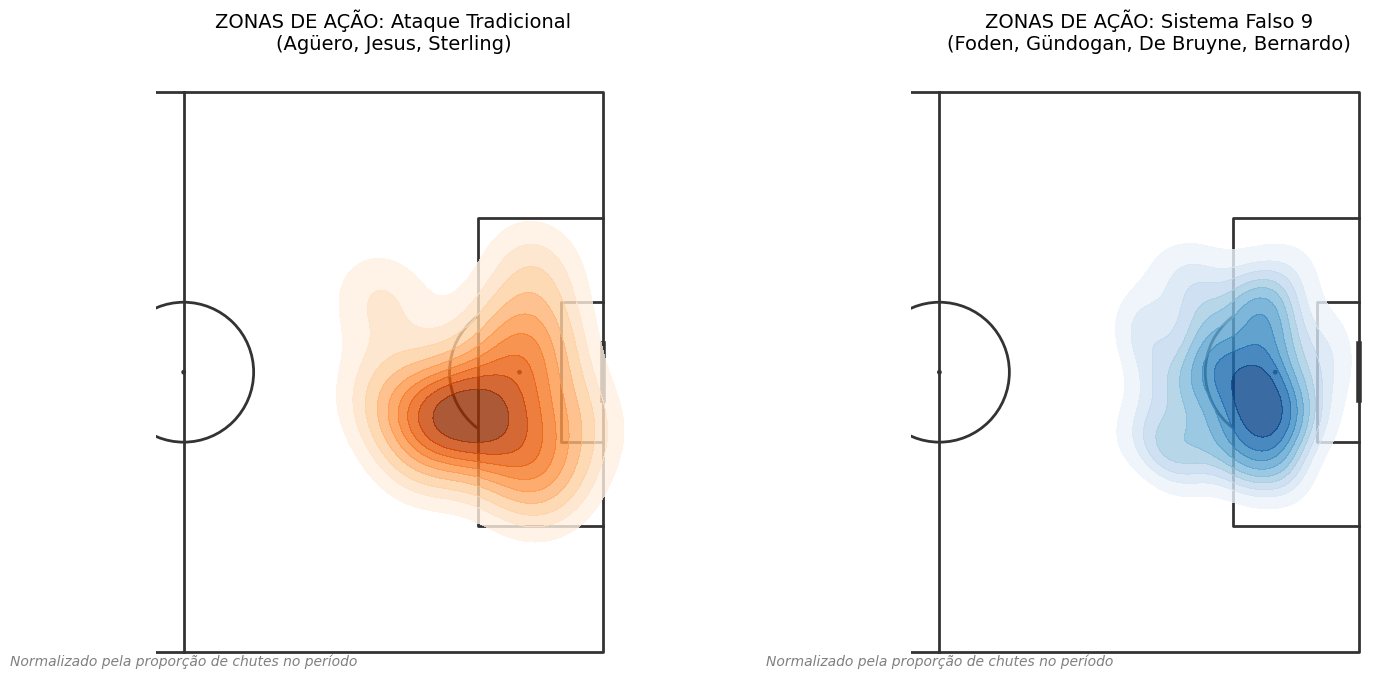

In [25]:
pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')

# =========================================================
# PLOT 1: Sistema Tradicional (Normalizado - Apenas KDE)
# =========================================================
if len(trad_shots_antes) > 2:
    # fill=True, thresh=0.1 (ignora os 10% mais raros para limpar bordas), alpha forte
    sns.kdeplot(x=trad_shots_antes['x_sb'], y=trad_shots_antes['y_sb'], ax=ax[0],
                fill=True, cmap='Oranges', thresh=0.1, levels=10, alpha=0.8)

ax[0].set_title(f'ZONAS DE AÇÃO: Ataque Tradicional\n(Agüero, Jesus, Sterling)', fontsize=14, pad=10)
# Subtítulo explicativo sobre a normalização
ax[0].text(60, 82, 'Normalizado pela proporção de chutes no período',
           fontsize=10, ha='center', color='gray', style='italic')

# =========================================================
# PLOT 2: Sistema Falso 9 (Normalizado - Apenas KDE)
# =========================================================
if len(falso9_shots_depois) > 2:
    sns.kdeplot(x=falso9_shots_depois['x_sb'], y=falso9_shots_depois['y_sb'], ax=ax[1],
                fill=True, cmap='Blues', thresh=0.1, levels=10, alpha=0.8)

ax[1].set_title(f'ZONAS DE AÇÃO: Sistema Falso 9\n(Foden, Gündogan, De Bruyne, Bernardo)', fontsize=14, pad=10)
ax[1].text(60, 82, 'Normalizado pela proporção de chutes no período',
           fontsize=10, ha='center', color='gray', style='italic')

plt.tight_layout()
plt.show()